In [1]:
import marimo as mo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import cars
from sklearn.preprocessing import StandardScaler

In [3]:
from pathlib import Path

# Résout le chemin relativement au notebook (et non au CWD), pour que
# ça marche aussi bien depuis VS Code que depuis marimo/localhost.
# On part du dossier du fichier et on remonte jusqu'à trouver "data/".
def _find_data_dir(start: Path) -> Path:
    for parent in [start, *start.parents]:
        candidate = parent / "data"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("Dossier 'data/' introuvable depuis " + str(start))

try:
    _base = Path(__file__).resolve().parent
except NameError:
    # __file__ peut être absent selon le mode d'exécution : on retombe sur le CWD.
    _base = Path.cwd()

data_dir = _find_data_dir(_base)
df = pd.read_csv(data_dir / "nhtsa_vehicle_safety_recall_intelligence_ultimate.csv")

df.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


# Pre-processing

In [4]:
recall = df['recall_type_label'].unique()
recall

<StringArray>
['Vehicle', 'Equipment', 'Child Seat', 'Tire']
Length: 4, dtype: str

In [5]:
df_1 = df[df['recall_type_label'].isin(['Vehicle'])]
df_1.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [6]:
_components = df_1['component_category'].unique()
_components

<StringArray>
[            'Air Bag', 'Engine / Powertrain',          'Electrical',
              'Brakes',            'Steering',         'Fuel System',
               'Other',      'Tires / Wheels',          'Visibility',
           'Fire Risk',          'Suspension',          'Seat Belts',
       'Software / EV',          'Child Seat']
Length: 14, dtype: str

In [7]:
df_2 = df_1[~df_1['component_category'].isin(['Child Seat', 'Other'])]
df_2.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,56617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [8]:
manufacturer_campaign_ids = df_2['manufacturer_campaign_id'].unique()
vehicle_year = df_2['vehicle_year'].unique()
vehicle_year_num = df_2['vehicle_year_num'].unique()
vehicle_era = df_2['vehicle_era'].unique()
print(manufacturer_campaign_ids)
print(vehicle_year)
print(vehicle_year_num)
print(vehicle_era)
# ATTENTION: df_2.dropna() supprimait ~98% des lignes (44984 -> 915) car des
# colonnes comme MFR_COMP_PTNO / manufacture_date_* sont presque vides.
# On ne supprime que les lignes nulles sur les colonnes réellement utilisées.
df_3 = df_2.dropna(subset=['vehicle_year_num', 'defect_severity', 'component_category'])
df_3 = df_3[(df_3['vehicle_year_num'] >= 2014) & (df_3['vehicle_year_num'] <= 2024)]

<StringArray>
[          '14350',          '17-307',           '8715J',             '251',
           'SC098',             'C0M',     '14113,14133',             'P25',
               nan,           'R22C8',
 ...
          '20TA06', '21TB10 / 21TA10',        'R20AM-SB',      'N212346640',
 'Bulletin 2020-5',        'RC000204',        'RVXX2005',            'N494',
          'TB2011',           'V2003']
Length: 3560, dtype: str
[1998. 2005. 2001. 2000. 2002. 2003. 2004. 1999. 1997. 2006. 2007. 2008.
 2014. 2010. 1993. 2011. 2016. 2013. 2017. 2015. 2009. 2012. 2018. 1989.
 2020. 2019. 2021. 2022. 2023. 1996. 1994. 1995. 2024. 1991. 1992. 1990.
 2025. 2026. 1988. 2027.   nan]
[1998. 2005. 2001. 2000. 2002. 2003. 2004. 1999. 1997. 2006. 2007. 2008.
 2014. 2010. 1993. 2011. 2016. 2013. 2017. 2015. 2009. 2012. 2018. 1989.
 2020. 2019. 2021. 2022. 2023. 1996. 1994. 1995. 2024. 1991. 1992. 1990.
 2025. 2026. 1988. 2027.   nan]
<StringArray>
['1990s', '2000s', '2010s', '1980s', '2020s', nan]
Len

# Analyse

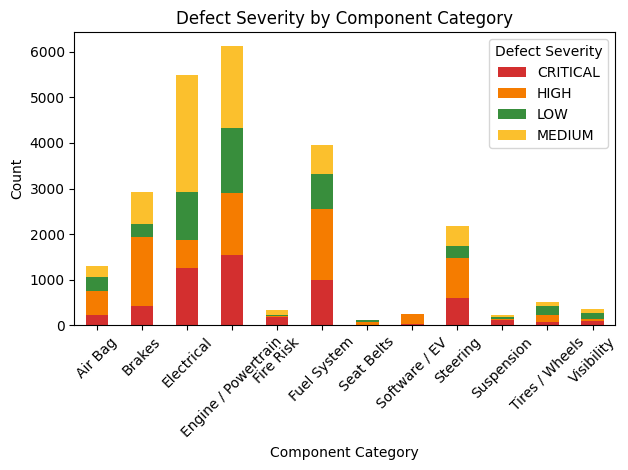

In [9]:
severity_colors = {'CRITICAL': '#d32f2f', 'HIGH': '#f57c00', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c'}
defect_severity_by_component = df_3.groupby('component_category')['defect_severity'].value_counts().unstack().fillna(0)
_colors = [severity_colors[col] for col in defect_severity_by_component.columns]
defect_severity_by_component.plot(kind='bar', stacked=True, color=_colors)
plt.title('Defect Severity by Component Category')
plt.xlabel('Component Category')
plt.ylabel('Count')
plt.legend(title='Defect Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
defect_severity = df_3['defect_severity'].unique()
defect_severity

<StringArray>
['CRITICAL', 'LOW', 'HIGH', 'MEDIUM']
Length: 4, dtype: str

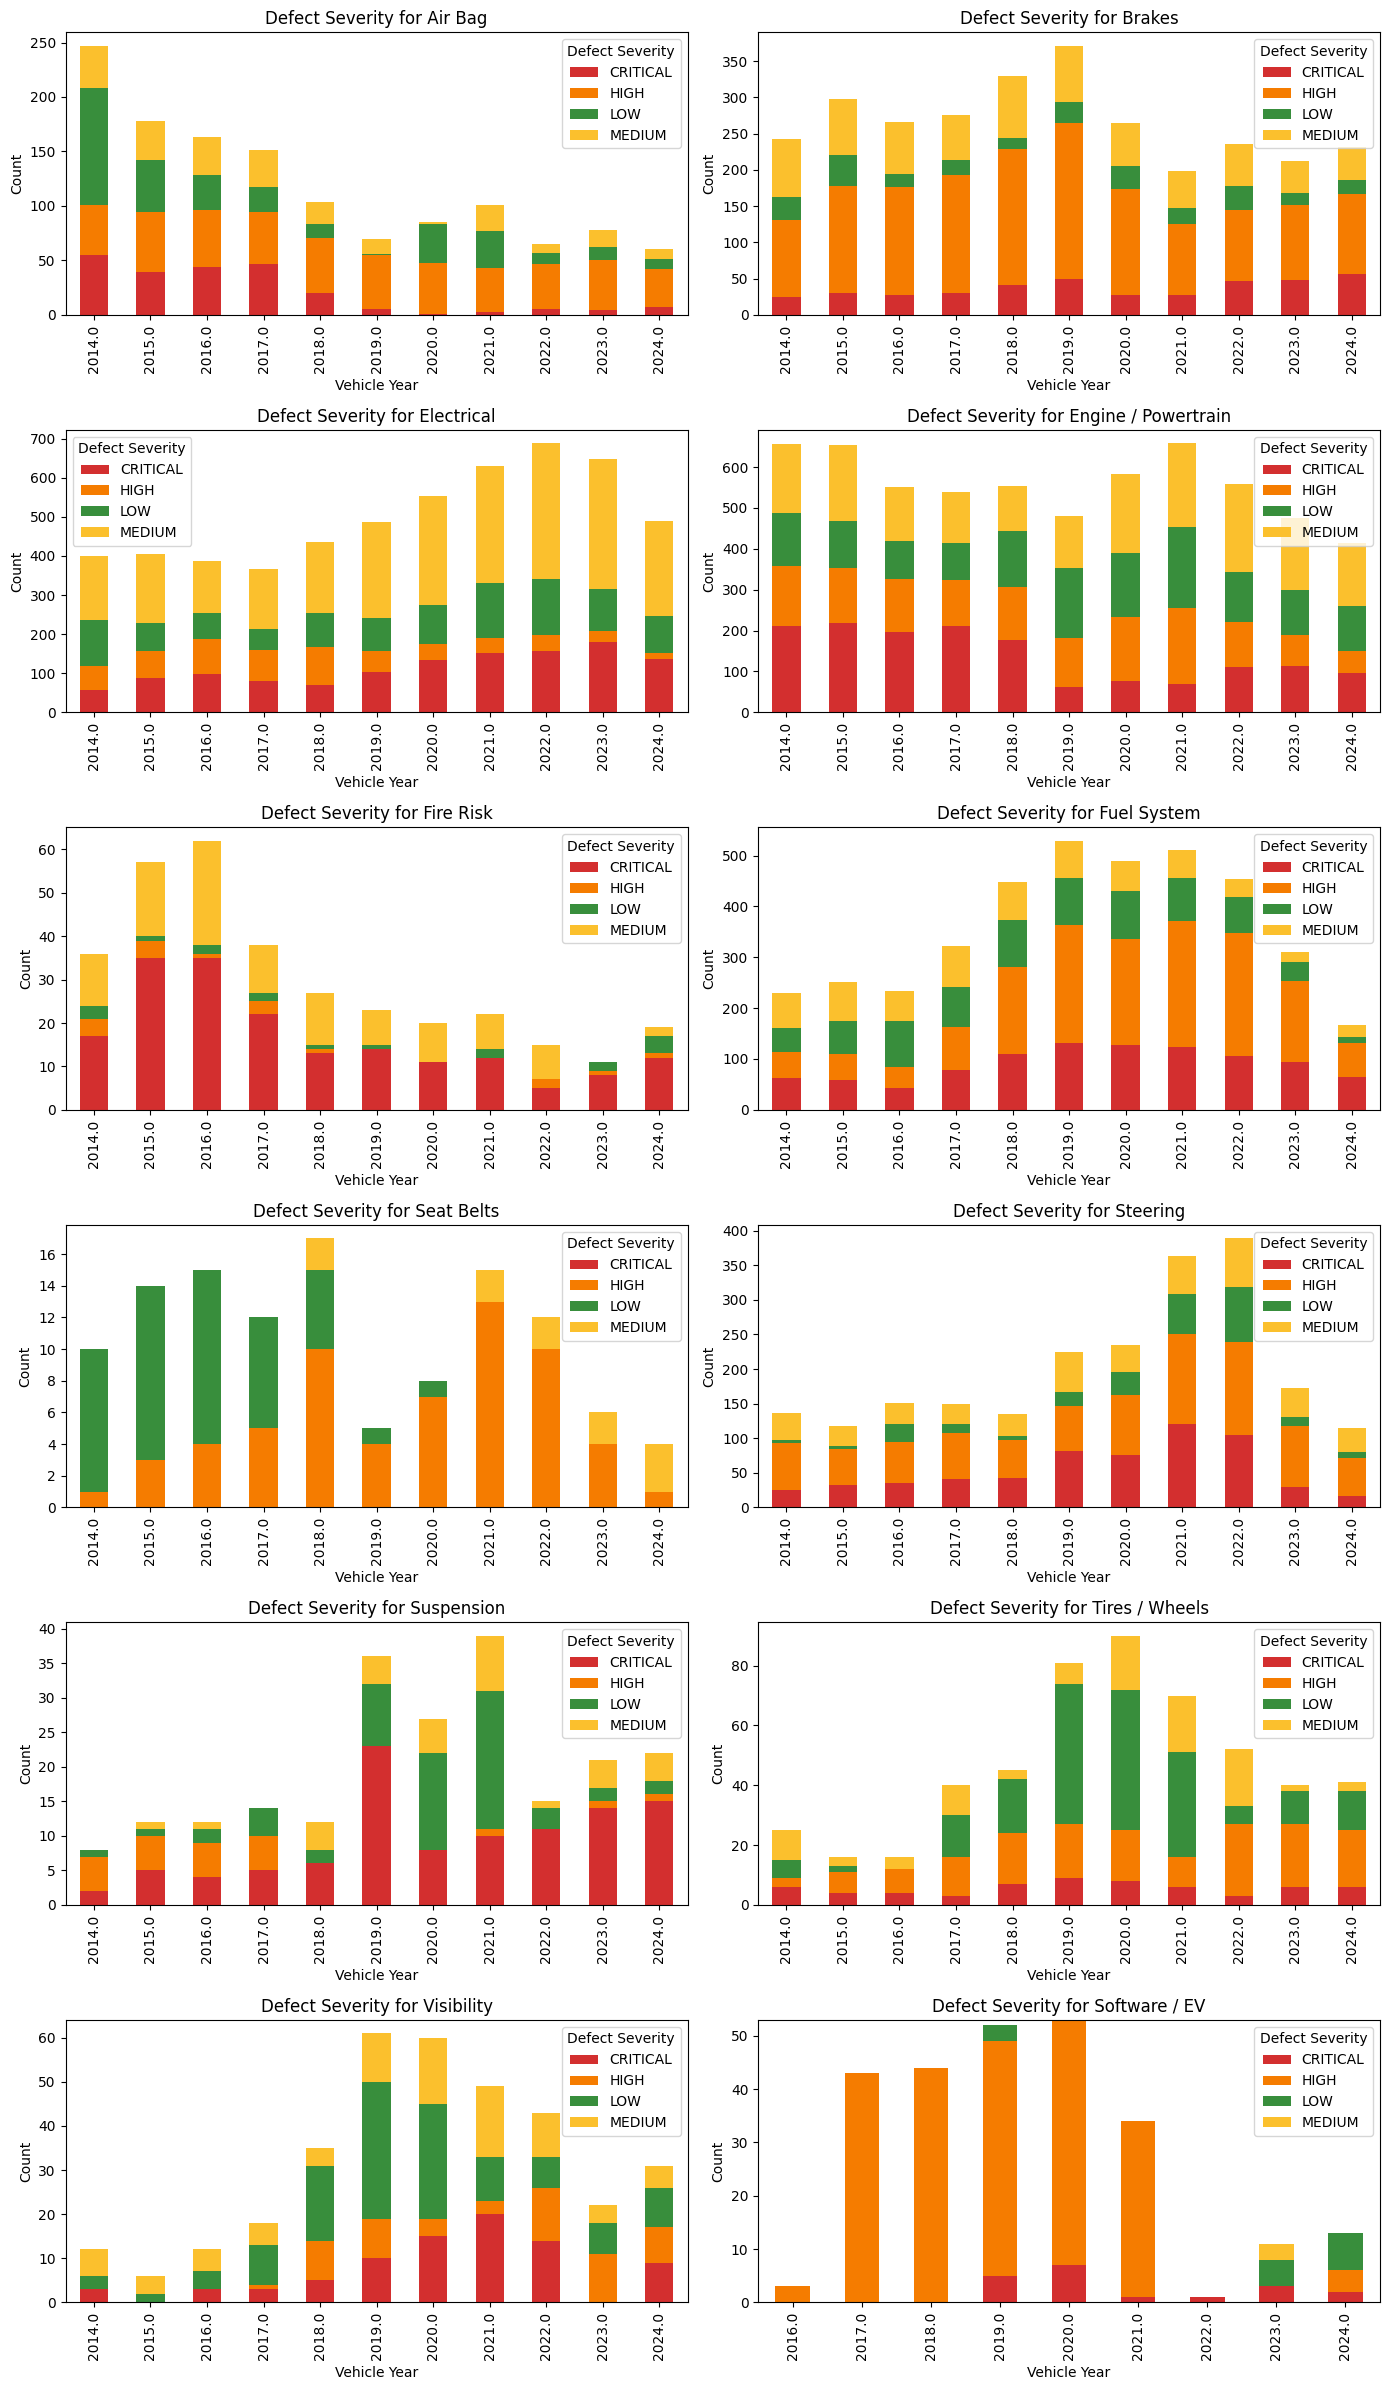

In [11]:
defect_severity_by_component_years = df_3.groupby(['vehicle_year_num', 'component_category'])['defect_severity'].value_counts().unstack().fillna(0)
severity_colors_1 = {'CRITICAL': '#d32f2f', 'HIGH': '#f57c00', 'MEDIUM': '#fbc02d', 'LOW': '#388e3c'}
_components = defect_severity_by_component_years.index.get_level_values(1).unique()
n_rows = (len(_components) + 1) // 2
_fig, _ax = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
_ax = _ax.flatten()
for i, component in enumerate(_components):
    data = defect_severity_by_component_years.xs(component, level=1)
    _colors = [severity_colors_1.get(col, '#90a4ae') for col in data.columns]
    data.plot(kind='bar', stacked=True, ax=_ax[i], color=_colors)
    _ax[i].set_title(f'Defect Severity for {component}')
    _ax[i].set_xlabel('Vehicle Year')
    _ax[i].set_ylabel('Count')
    _ax[i].legend(title='Defect Severity')
for j in range(len(_components), len(_ax)):
    _ax[j].set_visible(False)
plt.tight_layout()
plt.show()

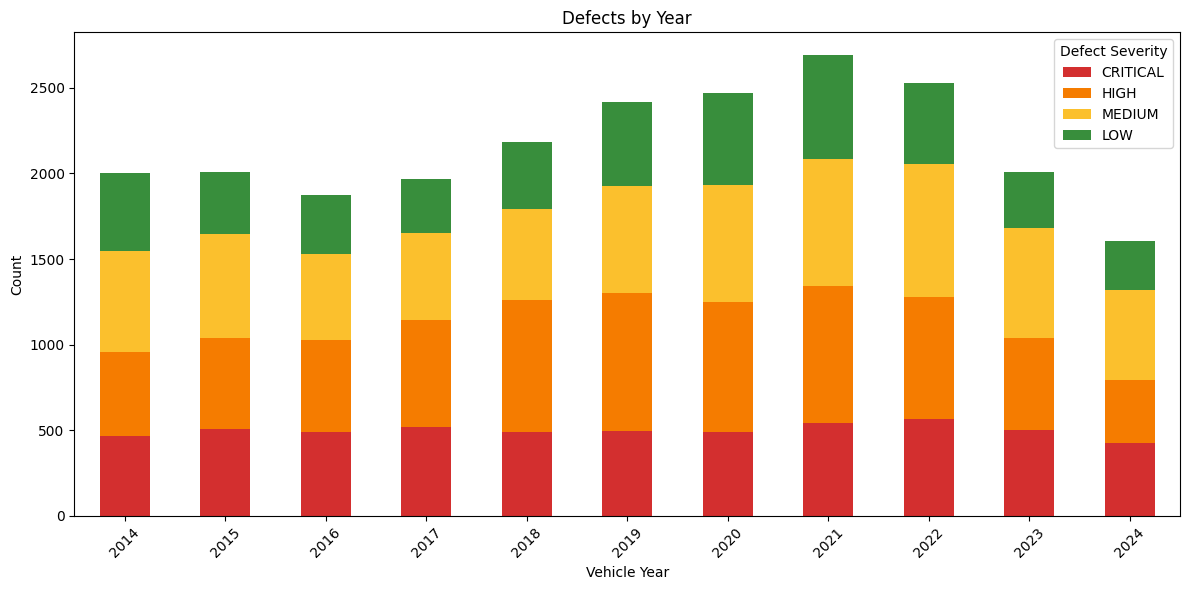

In [12]:
severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
defects_by_year = df_3.groupby(['vehicle_year_num', 'defect_severity']).size().unstack(fill_value=0).reindex(columns=severity_order)
_colors = [severity_colors_1[col] for col in defects_by_year.columns]
_fig, _ax = plt.subplots(figsize=(12, 6))
defects_by_year.plot(kind='bar', stacked=True, color=_colors, ax=_ax)
_ax.set_title('Defects by Year')
_ax.set_xlabel('Vehicle Year')
_ax.set_ylabel('Count')
_ax.legend(title='Defect Severity')
_ax.set_xticklabels([int(y) for y in defects_by_year.index], rotation=45)
plt.tight_layout()
plt.show()

Approach: going more into hybrid or electrical cars + cars fires

# Normalisation

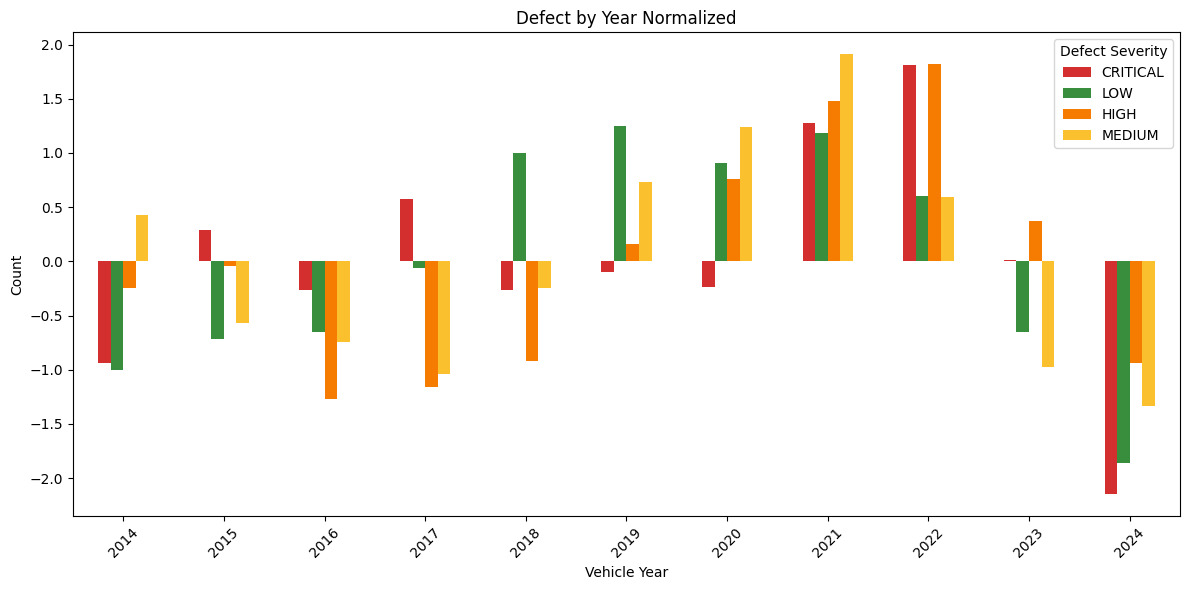

In [13]:
scaler = StandardScaler()
standardized_defect_by_year = scaler.fit_transform(defects_by_year)
standardized_defect_by_year = pd.DataFrame(standardized_defect_by_year, columns=defect_severity)

_colors = [severity_colors_1[col] for col in standardized_defect_by_year.columns]

_fig1, _ax1 = plt.subplots(figsize=(12, 6))
standardized_defect_by_year.plot(kind='bar', stacked=False, color=_colors, ax=_ax1)
_ax1.set_title('Defect by Year Normalized')
_ax1.set_xlabel('Vehicle Year')
_ax1.set_ylabel('Count')
_ax1.legend(title='Defect Severity')
_ax1.set_xticklabels([int(y) for y in defects_by_year.index], rotation=45)
plt.tight_layout()
plt.show()

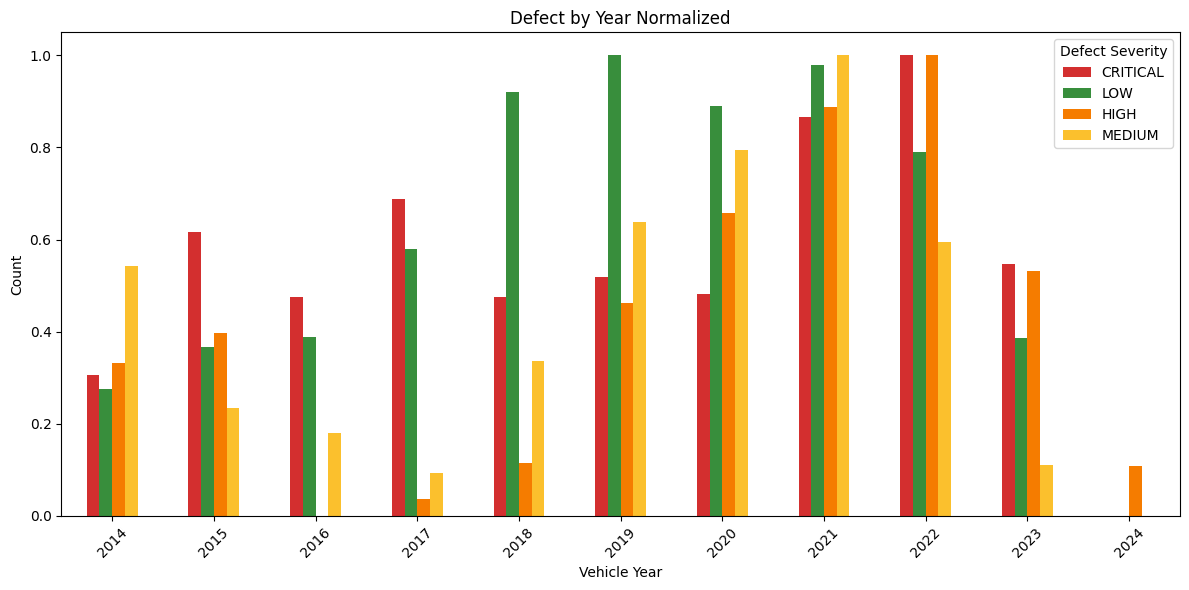

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler2 = MinMaxScaler()
standardized_defect_by_year2 = scaler2.fit_transform(defects_by_year)
standardized_defect_by_year2 = pd.DataFrame(
    standardized_defect_by_year2,
    columns=defect_severity,
    index=defects_by_year.index  # ← important pour garder les années en index
)
_colors = [severity_colors_1[col] for col in standardized_defect_by_year2.columns]
_fig3, _ax3 = plt.subplots(figsize=(12, 6))
standardized_defect_by_year2.plot(kind='bar', stacked=False, color=_colors, ax=_ax3)
_ax3.set_title('Defect by Year Normalized')
_ax3.set_xlabel('Vehicle Year')
_ax3.set_ylabel('Count')
_ax3.legend(title='Defect Severity')
_ax3.set_xticklabels([int(y) for y in defects_by_year.index], rotation=45)
plt.tight_layout()
plt.show()

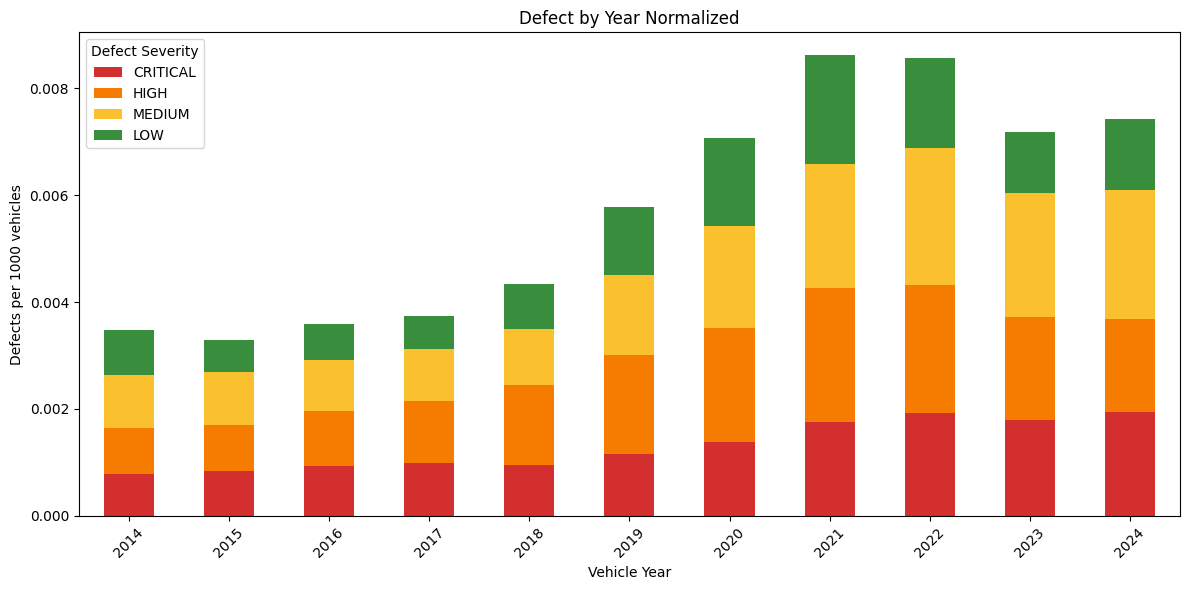

In [15]:
severity_counts = (
    df.groupby(['vehicle_year_num', 'defect_severity'])
    .size()
    .unstack(fill_value=0)
    .rename(columns=str.upper)
)

# ✅ Filtre sur l'index
severity_counts = severity_counts[(severity_counts.index >= 2014) & (severity_counts.index <= 2024)]

for _col in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    if _col not in severity_counts.columns:
        severity_counts[_col] = 0
severity_counts = severity_counts[['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']]

vehicle_per_year = (
    df.groupby('vehicle_year_num')['units_affected_num']
    .sum()
    .rename('nb_vehicles')
)

result = severity_counts.join(vehicle_per_year)

# ✅ Colonnes séparées pour le taux
for _col in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    result[f'{_col}_per_1000'] = (result[_col] / result['nb_vehicles']) * 1000

result = result.reset_index()

plot_data = result.set_index('vehicle_year_num')[['CRITICAL_per_1000', 'HIGH_per_1000', 'MEDIUM_per_1000', 'LOW_per_1000']]
_colors = [severity_colors_1[_col] for _col in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']]

_fig2, _ax2 = plt.subplots(figsize=(12, 6))
plot_data.plot(kind='bar', stacked=True, color=_colors, ax=_ax2)
_ax2.set_title('Defect by Year Normalized')
_ax2.set_xlabel('Vehicle Year')
_ax2.set_ylabel('Defects per 1000 vehicles')
_ax2.legend(title='Defect Severity', labels=['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])
_ax2.set_xticklabels([int(y) for y in plot_data.index], rotation=45)
plt.tight_layout()
plt.show()

# Rappel

In [16]:
df_3['recall_date_parsed'] = pd.to_datetime(df_3['recall_date_parsed'], format='%Y-%m-%d')
df_3['notification_date_parsed'] = pd.to_datetime(df_3['notification_date_parsed'], format='%Y-%m-%d')

df_3['jours_ecoules'] = (df_3['notification_date_parsed'] - df_3['recall_date_parsed']).dt.days.clip(lower=0)

df_3['jours_ecoules']

47       54.0
54       54.0
59       54.0
60       54.0
61       54.0
         ... 
47702    42.0
47703    42.0
47704    42.0
47705    42.0
47706    59.0
Name: jours_ecoules, Length: 23756, dtype: float64

In [17]:
df_3['jours_ecoules'] = (df_3['notification_date_parsed'] - df_3['recall_date_parsed']).dt.days

df_3['check'] = df_3['jours_ecoules'] - df_3['days_to_owner_notification']
df_3[['jours_ecoules', 'days_to_owner_notification', 'check']].describe()

,jours_ecoules,days_to_owner_notification,check
count,23064.000000,23064.000000,23064.000000
mean,71.302593,71.730316,-0.427723
std,82.069011,81.378046,7.181366
min,-269.000000,0.000000,-269.000000
25%,34.000000,34.000000,0.000000
50%,51.000000,51.000000,0.000000
75%,63.000000,63.000000,0.000000
max,2675.000000,2675.000000,0.000000


In [18]:
df_3[df_3['check'] < 0][['recall_date_parsed', 'notification_date_parsed', 'jours_ecoules', 'days_to_owner_notification', 'check']]

,recall_date_parsed,notification_date_parsed,jours_ecoules,days_to_owner_notification,check
5664,2014-03-24,2014-03-12,-12.0,0.0,-12.0
5667,2014-03-24,2014-03-12,-12.0,0.0,-12.0
5668,2014-03-24,2014-03-12,-12.0,0.0,-12.0
5677,2014-03-24,2014-03-12,-12.0,0.0,-12.0
5682,2014-03-24,2014-03-12,-12.0,0.0,-12.0
...,...,...,...,...,...
46896,2021-11-05,2021-10-29,-7.0,0.0,-7.0
46897,2021-11-05,2021-10-29,-7.0,0.0,-7.0
46898,2021-11-05,2021-10-29,-7.0,0.0,-7.0
46899,2021-11-05,2021-10-29,-7.0,0.0,-7.0


# Taux normalisé par la flotte (immatriculations)

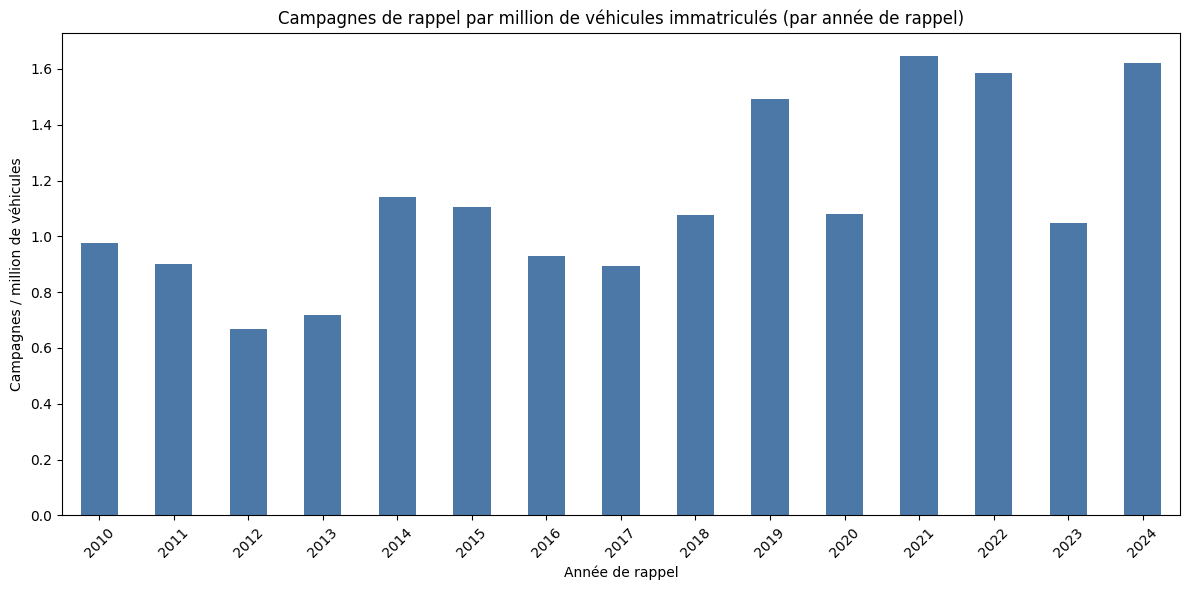

In [19]:
# Flotte immatriculée par année calendaire (national = somme de tous les États).
_reg = pd.read_csv(data_dir / "Motor_Vehicle_Registrations__1900_-_2024__MV-1_.csv")
fleet_per_year = (
    _reg[_reg['Category'].isin(['Auto', 'Truck'])]
    .groupby('Year')['Vehicles'].sum()
    .rename('fleet')
)

# Unité = campagne de rappel UNIQUE. Chaque ligne du dataset est un millésime/modèle
# d'une campagne (~9 lignes par campagne), donc on déduplique via recall_campaign_id.
_veh = df[df['recall_type_label'] == 'Vehicle']
campaigns_per_year = (
    _veh.groupby('recall_year')['recall_campaign_id'].nunique().rename('campaigns')
)

# Période commune aux deux sources (immatriculations: ... -> 2024).
recall_rate = pd.concat([campaigns_per_year, fleet_per_year], axis=1).dropna()
recall_rate = recall_rate[(recall_rate.index >= 2010) & (recall_rate.index <= 2024)]
recall_rate['per_million'] = recall_rate['campaigns'] / recall_rate['fleet'] * 1_000_000

_fig, _ax = plt.subplots(figsize=(12, 6))
recall_rate['per_million'].plot(kind='bar', color='#4C78A8', ax=_ax)
_ax.set_title('Campagnes de rappel par million de véhicules immatriculés (par année de rappel)')
_ax.set_xlabel('Année de rappel')
_ax.set_ylabel('Campagnes / million de véhicules')
_ax.set_xticklabels([int(y) for y in recall_rate.index], rotation=45)
plt.tight_layout()
plt.show()

# Over-engineering : montée de l'électronique / du logiciel

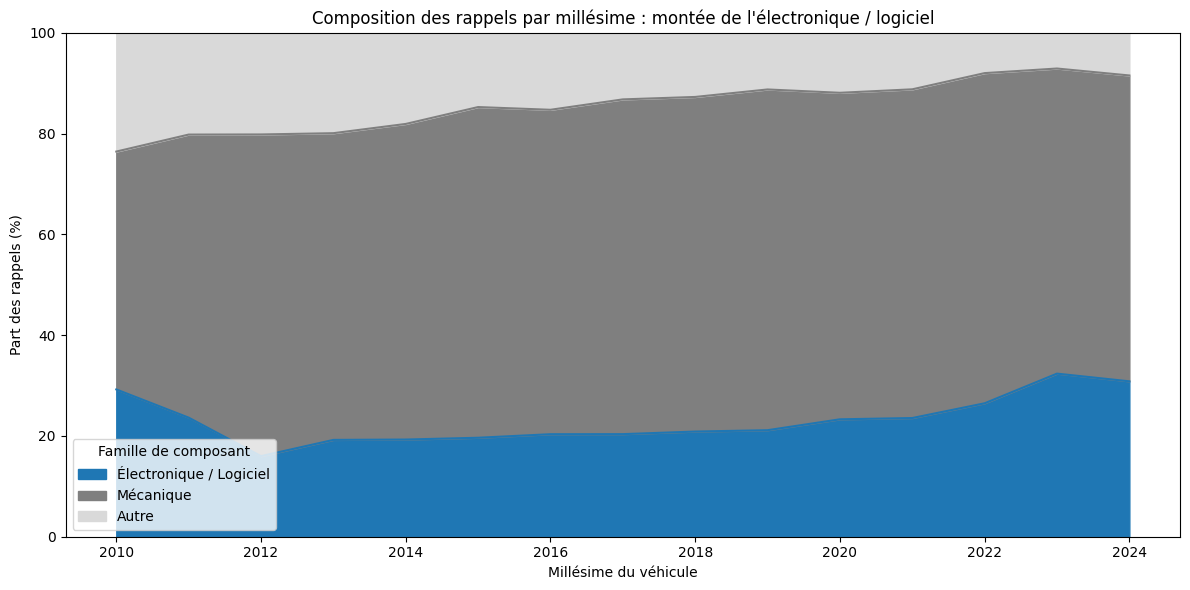

In [20]:
# Part des rappels par famille de composant et par millésime (composition, en %).
_v = df[df['recall_type_label'] == 'Vehicle'].dropna(subset=['vehicle_year_num', 'component_category'])
_v = _v[(_v['vehicle_year_num'] >= 2010) & (_v['vehicle_year_num'] <= 2024)]

_electronics = ['Electrical', 'Software / EV']
_mechanical = ['Engine / Powertrain', 'Brakes', 'Steering', 'Suspension', 'Tires / Wheels', 'Fuel System']

def _grp(c):
    if c in _electronics:
        return 'Électronique / Logiciel'
    if c in _mechanical:
        return 'Mécanique'
    return 'Autre'

_mix = (
    _v.assign(groupe=_v['component_category'].map(_grp))
    .groupby(['vehicle_year_num', 'groupe']).size()
    .unstack(fill_value=0)
)
component_share = _mix.div(_mix.sum(axis=1), axis=0) * 100
component_share = component_share[['Électronique / Logiciel', 'Mécanique', 'Autre']]

_fig, _ax = plt.subplots(figsize=(12, 6))
component_share.plot(kind='area', stacked=True, ax=_ax,
                     color=['#1f77b4', '#7f7f7f', '#d9d9d9'])
_ax.set_title("Composition des rappels par millésime : montée de l'électronique / logiciel")
_ax.set_xlabel('Millésime du véhicule')
_ax.set_ylabel('Part des rappels (%)')
_ax.set_ylim(0, 100)
_ax.legend(title='Famille de composant', loc='lower left')
plt.tight_layout()
plt.show()

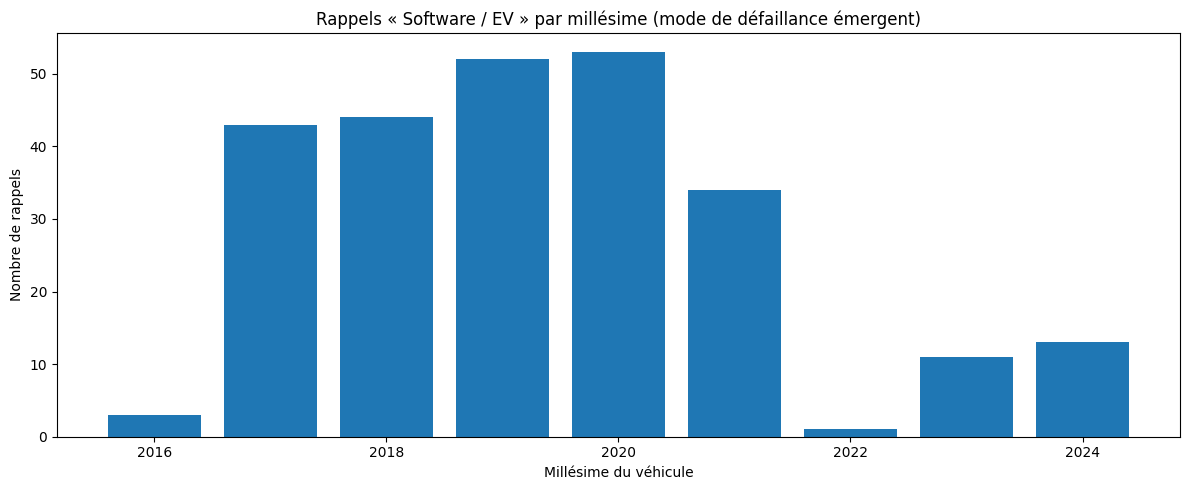

In [21]:
# Catégorie "Software / EV" : mode de défaillance quasi inexistant avant ~2016.
_v = df[df['recall_type_label'] == 'Vehicle'].dropna(subset=['vehicle_year_num', 'component_category'])
_sw = _v[_v['component_category'] == 'Software / EV'].groupby('vehicle_year_num').size()
_sw = _sw[(_sw.index >= 2010) & (_sw.index <= 2024)]

_fig, _ax = plt.subplots(figsize=(12, 5))
_ax.bar([int(y) for y in _sw.index], _sw.values, color='#1f77b4')
_ax.set_title("Rappels « Software / EV » par millésime (mode de défaillance émergent)")
_ax.set_xlabel('Millésime du véhicule')
_ax.set_ylabel('Nombre de rappels')
plt.tight_layout()
plt.show()